# CMFV with fluid sims


## Truth model:

Downstream conditions --> upstream conditions --> Pressure drop

1. Downstream
   1. Chamber
      1. Setpoint - Pressure, flow (mass/volume rate, velocity)
   2. Downstream plumbing
         1. Links Pressure/rate after valve and before chamber
2. Upstream
   1. Tank
      1. Flow (like velocity)
      2. Depleted according to flow
   2. Upstream plumbing
      1. Links pressure/flow rate after tank and before valve
3. Valve
   1. Pressure drop and angle

Chamber starts out at 0 gauge pressure (1 atmosphere absolute) and valve angle at 90 (fully closed)

Each step
- Known states
  - Tank mass -> pressure
  - Actual chamber pressure
  - Valve angle and coefficient
- Solve flow
  - P_tank + P_chamber = dP_upstream(m_dot) + dP_downstream(m_dot) + dP_valve(m_dot, angle)
  - Via bisection maybe
- Update
  - tank mass
  - Chamber m_dot and pressure

Solving for truth
- Solve pressure equations to get flow rate and pressure drop across valve
  - Valve angle is a known based on truth
- Update tank mass and chamber pressure based on flow rate

Controller
- Get actual angle and downstream pressure
- Calculate error and update angle

## Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable
from dataclasses import dataclass

from cmfv import PressureTransducer, Servo, Valve, RAD_TO_DEG, DEG_TO_RAD, PController, CmfvSimInputs, CmfvSimInitialConditions, Controller, CmfvSimOutputs

### Sanity Check

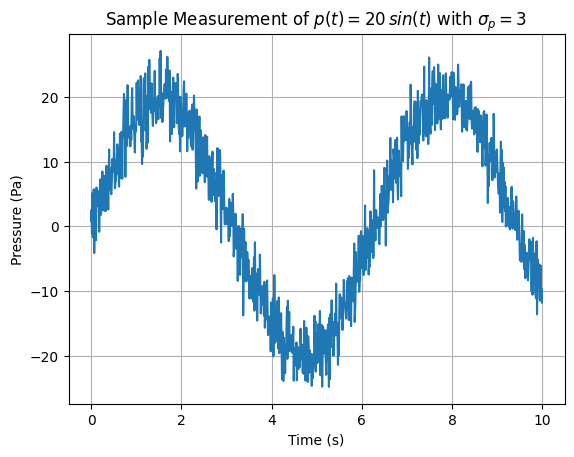

In [ ]:
dt = 0.01
ts = np.arange(1000)*dt

sigma_p = 3 # Pa

ps = 20*np.sin(ts)
ducer = PressureTransducer(sigma_p, 0)
p_hat = [ducer.observe(p) for p in ps]

plt.title(rf"Sample Measurement of $p(t) = 20\,sin(t)$ with $\sigma_p = {sigma_p}$")
plt.xlabel("Time (s)")
plt.ylabel("Pressure (Pa)")
plt.plot(ts, p_hat )
plt.grid()
plt.show()